# **RAG CHATBOT**

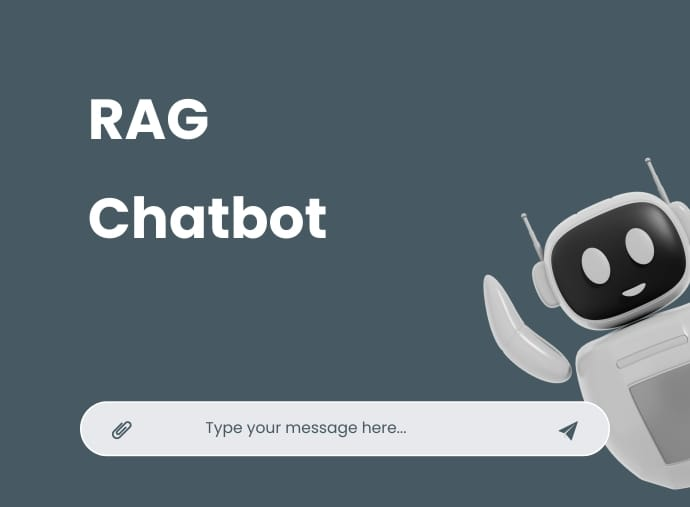

installation process

In [1]:
!pip install -q sentence-transformers langchain faiss-cpu langchain-community Pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


 files Uploading part

In [2]:
from langchain_community.document_loaders import PyPDFLoader

In [3]:
from google.colab import files
uploaded = files.upload()
files_name = next(iter(uploaded))

from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("/content/the public domain book.pdf")
documents = loader.load()

Saving the public domain book.pdf to the public domain book (1).pdf


splitting into chunks

In [4]:
from langchain.text_splitter import CharacterTextSplitter
splitter = CharacterTextSplitter(chunk_size = 500, chunk_overlap = 50)
chunks = splitter.split_documents(documents)

from HUGGINGFACE

In [5]:
from langchain.embeddings import HuggingFaceBgeEmbeddings
embedding_model = HuggingFaceBgeEmbeddings(model_name = "all-MiniLM-L6-v2")

/tmp/ipython-input-3498701802.py:2: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceBgeEmbeddings(model_name = "all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS PART

In [6]:
from langchain.vectorstores import FAISS

vector_db =  FAISS.from_documents(chunks, embedding_model)

summerising the model

In [7]:
query = input("enter your question")

revelant_docs = vector_db.similarity_search(query, k= 3)

for i,doc in enumerate(revelant_docs,1):
  print(f"--- Chunk {i} ---\n{doc.page_content}\n")

enter your questionwhat is the name of main character
--- Chunk 1 ---
39. See note 19 of this chapter for a discussion of the most recent and thoughtful challenge
to this claim.
40. Lord King, The Life of John Locke with Extracts from His Correspondence, Journals and
Common-Place Books vol. 1 (London: Henry Colburn, 1830), 379–380.
41. Archives de la Pr éfecture de Police de Paris, ser. AA, carton 200, feuilles 182 –183,
“Procès-verbal de police, section de St. Geneviève, 23–24 octobre 1791.” Quoted in
Carla Hesse, Publishing and Cultural Politics in Revolutionary Paris, 1789–1810(Berkeley:
University of California Press, 1991), 91.
42. Quoted in Hesse, Publishing and Cultural Politics, 100.
43. Victor Hugo, speech to the Conseil d’Etat, September 30, 1849, quoted in Bernard
Edelman, Ownership of the Image: Elements for a Marxist Theory of Law(London: Rout-
ledge & Kegan Paul, 1979), 41.
44. Oeuvres de Condorcet, ed. A. Condorcet O’Connor and M. F . Arago, vol. 11 (Paris:
Firmin Didot 